In [1]:
from sklearn.datasets import load_iris
iris_dataset = load_iris()

In [2]:
print("Keys of iris_dataset: \n{}".format(iris_dataset.keys()))

Keys of iris_dataset: 
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [3]:
print(iris_dataset['DESCR'][:] + "\n...")

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

In [4]:
print("Target names: {}".format(iris_dataset['target_names']))

Target names: ['setosa' 'versicolor' 'virginica']


In [5]:
print("Feature names: \n{}".format(iris_dataset['feature_names']))

Feature names: 
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [6]:
print("Type of data: {}".format(type(iris_dataset['data'])))

Type of data: <class 'numpy.ndarray'>


In [7]:
print("Shape of data: {}".format(iris_dataset['data'].shape))

Shape of data: (150, 4)


In [8]:
print("First five columns of data:\n{}".format(iris_dataset['data'][:5]))

First five columns of data:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [9]:
print("Type of target: {}".format(type(iris_dataset['target'])))

Type of target: <class 'numpy.ndarray'>


In [10]:
print("Shape of target: {}".format(iris_dataset['target'].shape))

Shape of target: (150,)


In [11]:
print("Target:\n{}".format(iris_dataset['target']))

Target:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [12]:
# 0 means setosa, 1 means versicolor, and 2 means virginica

In [13]:
# function shuffles the dataset using a pseudorandom number generator to prevent picking data from the same class
# if the data is sorted in a particular order, hence random = 0

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
iris_dataset['data'], iris_dataset['target'], random_state=0)

In [14]:
print("X_train shape: {}".format(X_train.shape))
print("y_train shape: {}".format(y_train.shape))

X_train shape: (112, 4)
y_train shape: (112,)


In [15]:
print("X_test shape: {}".format(X_test.shape))
print("y_test shape: {}".format(y_test.shape))

X_test shape: (38, 4)
y_test shape: (38,)


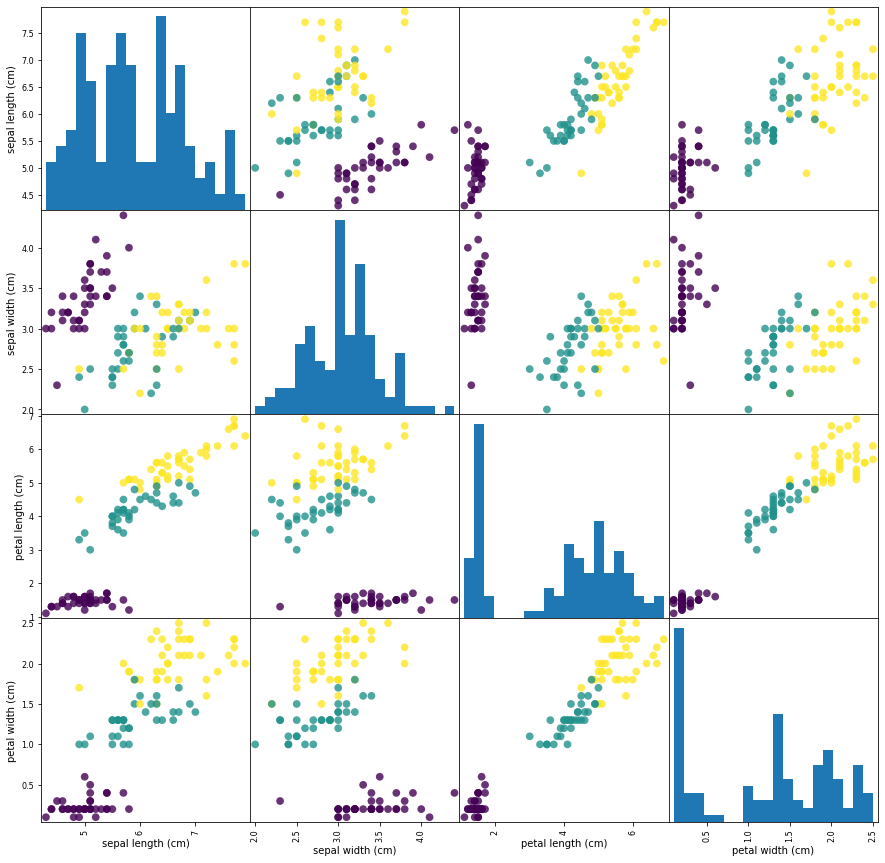

In [16]:
# create dataframe from data in X_train
# label the columns using the strings in iris_dataset.feature_names
import pandas as pd
import seaborn as sns

# import mglearn

iris_dataframe = pd.DataFrame(X_train, columns=iris_dataset.feature_names)
#create a scatter matrix from the dataframe, color by y_train
# grr = sns.pairplot(df)

grr = pd.plotting.scatter_matrix(iris_dataframe, c=y_train, figsize=(15, 15), marker='o',
hist_kwds={'bins': 20}, s=60, alpha=.8)

In [17]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)

In [18]:
model = knn.fit(X_train, y_train)
print(model)

KNeighborsClassifier(n_neighbors=1)


In [19]:
import numpy as np
X_new = np.array([[5, 2.9, 1, 0.2]])
print("X_new.shape: {}".format(X_new.shape))


X_new.shape: (1, 4)


In [20]:
prediction = knn.predict(X_new)
print("Prediction: {}".format(prediction))
print("Predicted target name: {}".format(
 iris_dataset['target_names'][prediction]))

Prediction: [0]
Predicted target name: ['setosa']


In [21]:
y_pred = knn.predict(X_test)
print("Test set predictions:\n {}".format(y_pred))


Test set predictions:
 [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]


In [22]:
print("Test set score: {:.2f}".format(np.mean(y_pred == y_test)))


Test set score: 0.97


In [23]:
print("Test set score: {:.2f}".format(knn.score(X_test, y_test)))

Test set score: 0.97


In [24]:
#  the larger variety of data points yor dataset contains, the more complex a model you can use without overfitting

In [25]:
# generate dataset

import sys
!{sys.executable} -m pip install mglearn


X.shape: (26, 2)


C:\Users\USER\AppData\Roaming\Python\Python38\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function make_blobs is deprecated; Please import make_blobs directly from scikit-learn
  warnings.warn(msg, category=FutureWarning)


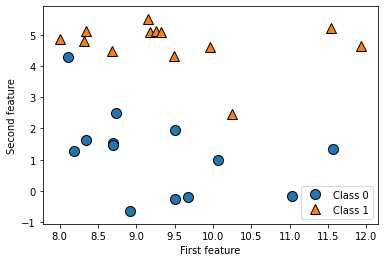

In [26]:
import matplotlib.pyplot as plt
import mglearn
from sklearn.datasets import make_blobs
from sklearn.datasets import make_classification

# generate dataset
# X,y = make_blobs()
# plot dataset
# plt.scatter(X[:, 0], X[:, 1], y)


# generate dataset
X, y = mglearn.datasets.make_forge()
# plot dataset
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.legend(["Class 0", "Class 1"], loc=4)
plt.xlabel("First feature")
plt.ylabel("Second feature")
print("X.shape: {}".format(X.shape))



X.shape: (100, 2)


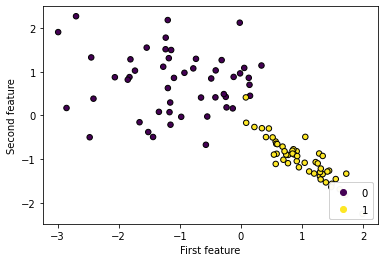

In [27]:
# generate dataset
X, y = make_classification(n_features=2, n_redundant=0, n_informative=2, n_clusters_per_class=1)
# plot dataset
fig, ax  = plt.subplots()
scatter = ax.scatter(X[:, 0], X[:, 1], marker="o", c=y, s=30, edgecolor="k")
legend1 = ax.legend(*scatter.legend_elements(),
                    loc=4)
ax.add_artist(legend1)
# plt.legend(scatter.legend_elements(), loc=1)
plt.xlabel("First feature")
plt.ylabel("Second feature")
print("X.shape: {}".format(X.shape))

Text(0, 0.5, 'Target')

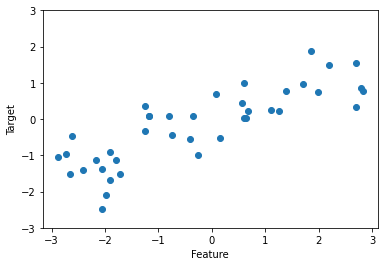

In [28]:
X, y = mglearn.datasets.make_wave(n_samples=40)
plt.plot(X, y, 'o')
plt.ylim(-3, 3)
plt.xlabel("Feature")
plt.ylabel("Target")


In [29]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
print("cancer.keys(): \n{}".format(cancer.keys()))


cancer.keys(): 
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [30]:
print("Shape of cancer data: {}".format(cancer.data.shape))


Shape of cancer data: (569, 30)


In [31]:
print("Sample counts per class:\n{}".format(
 {n: v for n, v in zip(cancer.target_names, np.bincount(cancer.target))}))

Sample counts per class:
{'malignant': 212, 'benign': 357}


In [32]:
print("Feature names:\n{}".format(cancer.feature_names))

Feature names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [33]:
from sklearn.datasets import load_boston
boston = load_boston()
print("Data shape: {}".format(boston.data.shape))


Data shape: (506, 13)


C:\Users\USER\AppData\Roaming\Python\Python38\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function load_boston is deprecated; `load_boston` is deprecated in 1.0 and will be removed in 1.2.

    The Boston housing prices dataset has an ethical problem. You can refer to
    the documentation of this function for further details.

    The scikit-learn maintainers therefore strongly discourage the use of this
    dataset unless the purpose of the code is to study and educate about
    ethical issues in data science and machine learning.

    In this special case, you can fetch the dataset from the original
    source::

        import pandas as pd
        import numpy as np

        data_url = "http://lib.stat.cmu.edu/datasets/boston"
        raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
        data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
        target = raw_df.values[1::2, 2]

    Alternative datasets include the California h

C:\Users\USER\AppData\Roaming\Python\Python38\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function make_blobs is deprecated; Please import make_blobs directly from scikit-learn
  warnings.warn(msg, category=FutureWarning)


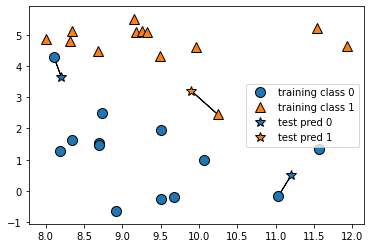

In [34]:
# k-Neighbors Classification

mglearn.plots.plot_knn_classification(n_neighbors=1)

C:\Users\USER\AppData\Roaming\Python\Python38\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function make_blobs is deprecated; Please import make_blobs directly from scikit-learn
  warnings.warn(msg, category=FutureWarning)


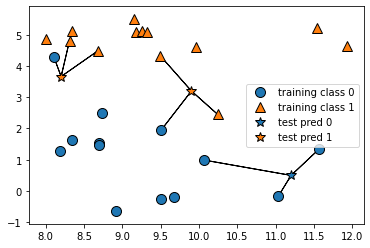

In [35]:
mglearn.plots.plot_knn_classification(n_neighbors=3)


In [36]:
from sklearn.model_selection import train_test_split
X, y = mglearn.datasets.make_forge()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)


C:\Users\USER\AppData\Roaming\Python\Python38\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function make_blobs is deprecated; Please import make_blobs directly from scikit-learn
  warnings.warn(msg, category=FutureWarning)


In [37]:
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3)

clf.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [38]:
print("Test set predictions: {}".format(clf.predict(X_test)))


Test set predictions: [1 0 1 0 1 0 0]


In [39]:
print("Test set accuracy: {:.2f}".format(clf.score(X_test, y_test)))


Test set accuracy: 0.86


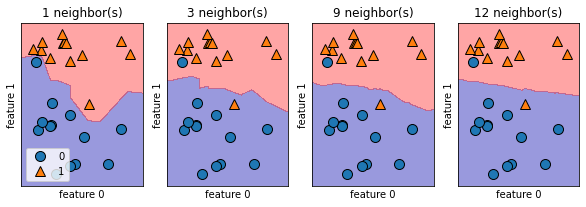

In [49]:
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for n_neighbors, ax in zip([1, 3, 9,12], axes):
 # the fit method returns the object self, so we can instantiate
 # and fit in one line
 clf = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X, y)
 mglearn.plots.plot_2d_separator(clf, X, fill=True, eps=0.5, ax=ax, alpha=.4)
 mglearn.discrete_scatter(X[:, 0], X[:, 1], y, ax=ax)
 ax.set_title("{} neighbor(s)".format(n_neighbors))
 ax.set_xlabel("feature 0")
 ax.set_ylabel("feature 1")
axes[0].legend(loc=3)


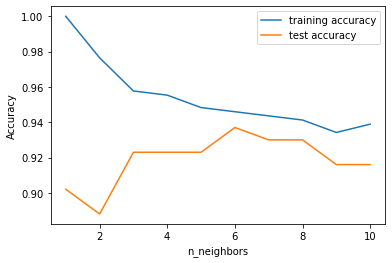

In [41]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
 cancer.data, cancer.target, stratify=cancer.target, random_state=66)
training_accuracy = []
test_accuracy = []
# try n_neighbors from 1 to 10
neighbors_settings = range(1, 11)
for n_neighbors in neighbors_settings:
 # build the model
 clf = KNeighborsClassifier(n_neighbors=n_neighbors)
 clf.fit(X_train, y_train)
 # record training set accuracy
 training_accuracy.append(clf.score(X_train, y_train))
 # record generalization accuracy
 test_accuracy.append(clf.score(X_test, y_test))
plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()


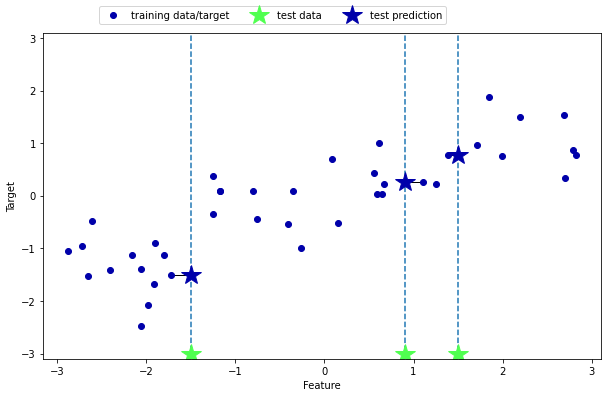

In [42]:
# k-neighbors regression
mglearn.plots.plot_knn_regression(n_neighbors=1)


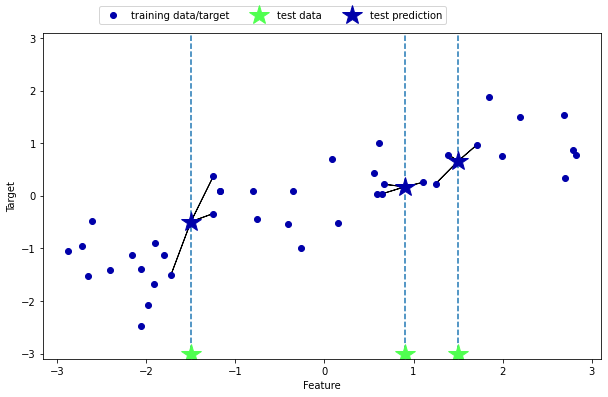

In [50]:
mglearn.plots.plot_knn_regression(n_neighbors=3)


In [51]:
from sklearn.neighbors import KNeighborsRegressor
X, y = mglearn.datasets.make_wave(n_samples=40)
# split the wave dataset into a training and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
# instantiate the model and set the number of neighbors to consider to 3
reg = KNeighborsRegressor(n_neighbors=3)
# fit the model using the training data and training targets
reg.fit(X_train, y_train)


KNeighborsRegressor(n_neighbors=3)

In [52]:
print("Test set predictions:\n{}".format(reg.predict(X_test)))

Test set predictions:
[-0.05396539  0.35686046  1.13671923 -1.89415682 -1.13881398 -1.63113382
  0.35686046  0.91241374 -0.44680446 -1.13881398]


In [53]:
print("Test set R^2: {:.2f}".format(reg.score(X_test, y_test)))

Test set R^2: 0.83


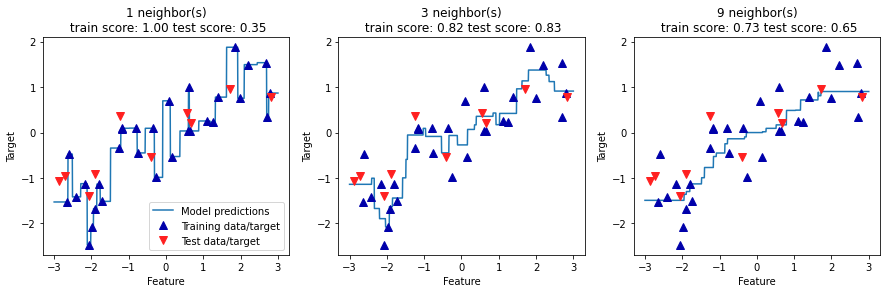

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# create 1,000 data points, evenly spaced between -3 and 3
line = np.linspace(-3, 3, 1000).reshape(-1, 1)
for n_neighbors, ax in zip([1, 3, 9], axes):
 # make predictions using 1, 3, or 9 neighbors
 reg = KNeighborsRegressor(n_neighbors=n_neighbors)
 reg.fit(X_train, y_train)
 ax.plot(line, reg.predict(line))
 ax.plot(X_train, y_train, '^', c=mglearn.cm2(0), markersize=8)
 ax.plot(X_test, y_test, 'v', c=mglearn.cm2(1), markersize=8)
 ax.set_title(
 "{} neighbor(s)\n train score: {:.2f} test score: {:.2f}".format(
 n_neighbors, reg.score(X_train, y_train),
 reg.score(X_test, y_test)))
 ax.set_xlabel("Feature")
 ax.set_ylabel("Target")
axes[0].legend(["Model predictions", "Training data/target",
 "Test data/target"], loc="best")


In [56]:
# lINEAR MODELS

w[0]: 0.393906  b: -0.031804


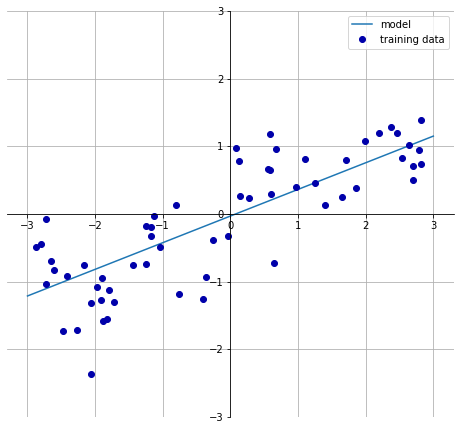

In [55]:
mglearn.plots.plot_linear_regression_wave()


In [57]:
# lINEAR REGRESSION (ordinary LS)

from sklearn.linear_model import LinearRegression
X, y = mglearn.datasets.make_wave(n_samples=60)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
lr = LinearRegression().fit(X_train, y_train)


In [58]:
# slope = coef_, intercept = intercept_
print("lr.coef_: {}".format(lr.coef_))
print("lr.intercept_: {}".format(lr.intercept_))


lr.coef_: [0.39390555]
lr.intercept_: -0.031804343026759746


In [59]:
print("Training set score: {:.2f}".format(lr.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lr.score(X_test, y_test)))


Training set score: 0.67
Test set score: 0.66


In [65]:
X, y = mglearn.datasets.load_extended_boston()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
lr = LinearRegression().fit(X_train, y_train)

C:\Users\USER\AppData\Roaming\Python\Python38\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function load_boston is deprecated; `load_boston` is deprecated in 1.0 and will be removed in 1.2.

    The Boston housing prices dataset has an ethical problem. You can refer to
    the documentation of this function for further details.

    The scikit-learn maintainers therefore strongly discourage the use of this
    dataset unless the purpose of the code is to study and educate about
    ethical issues in data science and machine learning.

    In this special case, you can fetch the dataset from the original
    source::

        import pandas as pd
        import numpy as np

        data_url = "http://lib.stat.cmu.edu/datasets/boston"
        raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
        data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
        target = raw_df.values[1::2, 2]

    Alternative datasets include the California h

In [ ]:
# # example of working with a Bunch object, which in this case is the dataset you're importing from sklearn

# from sklearn.datasets import fetch_rcv1
# rcv1 = fetch_rcv1()

# print(rcv1.DESCR)

# which outputs

# . _rcv1_dataset:

# RCV1 dataset
# ------------

# Reuters Corpus Volume I (RCV1) is an archive of over 800,000 manually 
# categorized newswire stories made available by Reuters, Ltd. for research 
# purposes. The dataset is extensively described in [1]_.

# **Data Set Characteristics:**

#     ==============     =====================
#     Classes                              103
#     Samples total                     804414
#     Dimensionality                     47236
#     Features           real, between 0 and 1
#     ==============     =====================

# :func:`sklearn.datasets.fetch_rcv1` will load the following 
# version: RCV1-v2, vectors, full sets, topics multilabels::

#     >>> from sklearn.datasets import fetch_rcv1
#     >>> rcv1 = fetch_rcv1()

# It returns a dictionary-like object, with the following attributes:

# ``data``:
# The feature matrix is a scipy CSR sparse matrix, with 804414 samples and
# 47236 features. Non-zero values contains cosine-normalized, log TF-IDF vectors.
# A nearly chronological split is proposed in [1]_: The first 23149 samples are
# the training set. The last 781265 samples are the testing set. This follows 
# the official LYRL2004 chronological split. The array has 0.16% of non zero 
# values::

#     >>> rcv1.data.shape
#     (804414, 47236)

# ``target``:
# The target values are stored in a scipy CSR sparse matrix, with 804414 samples 
# and 103 categories. Each sample has a value of 1 in its categories, and 0 in 
# others. The array has 3.15% of non zero values::

#     >>> rcv1.target.shape
#     (804414, 103)

# ``sample_id``:
# Each sample can be identified by its ID, ranging (with gaps) from 2286 
# to 810596::

#     >>> rcv1.sample_id[:3]
#     array([2286, 2287, 2288], dtype=uint32)

# ``target_names``:
# The target values are the topics of each sample. Each sample belongs to at 
# least one topic, and to up to 17 topics. There are 103 topics, each 
# represented by a string. Their corpus frequencies span five orders of 
# magnitude, from 5 occurrences for 'GMIL', to 381327 for 'CCAT'::

#     >>> rcv1.target_names[:3].tolist()  # doctest: +SKIP
#     ['E11', 'ECAT', 'M11']

# The dataset will be downloaded from the `rcv1 homepage`_ if necessary.
# The compressed size is about 656 MB.

# .. _rcv1 homepage: http://jmlr.csail.mit.edu/papers/volume5/lewis04a/


# .. topic:: References

#     .. [1] Lewis, D. D., Yang, Y., Rose, T. G., & Li, F. (2004). 
#            RCV1: A new benchmark collection for text categorization research. 
#            The Journal of Machine Learning Research, 5, 361-397.

# X_train = rcv1.data[0:23149,]
# X.train.shape
# # (23149, 47236)

# X_test = rcv1.data[23149:,]
# X_test.shape
# # (781265, 47236)

# and similarly for your y_train and y_test, using rcv1.target.

# y_train = rcv1.target[0:23149,]
# y_test = rcv1.target[23149:,]


In [74]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [75]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
housing['data'], housing['target'], random_state=0)

In [76]:
X_train.shape

(15480, 8)

In [77]:
X_test.shape

(5160, 8)

In [79]:
y_train.shape


(15480,)

In [80]:
y_test.shape

(5160,)

In [81]:
lr = LinearRegression().fit(X_train, y_train)


In [82]:
print("Training set score: {:.2f}".format(lr.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lr.score(X_test, y_test)))


Training set score: 0.61
Test set score: 0.59


In [ ]:
# Ridge Regression
